In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import confusion_matrix
from sklearn.metrics import r2_score


In [2]:
titanic = pd.read_csv("train.csv")
titanic.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
titanic.shape

(891, 12)

In [4]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
titanic.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
titanic.drop('Cabin', axis= 1, inplace = True)

In [8]:
titanic["Age"].fillna(titanic["Age"].median(),inplace =True)

C:\Users\HP\AppData\Local\Temp\ipykernel_15716\2852156880.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic["Age"].fillna(titanic["Age"].median(),inplace =True)


In [9]:
titanic["Embarked"].fillna(titanic["Embarked"].mode(),inplace =True)

C:\Users\HP\AppData\Local\Temp\ipykernel_15716\3437666717.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic["Embarked"].fillna(titanic["Embarked"].mode(),inplace =True)


In [10]:
titanic['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [11]:
titanic.groupby("Sex")["Survived"].mean()*100

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

In [12]:
titanic.groupby("Pclass")["Survived"].mean()*100

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

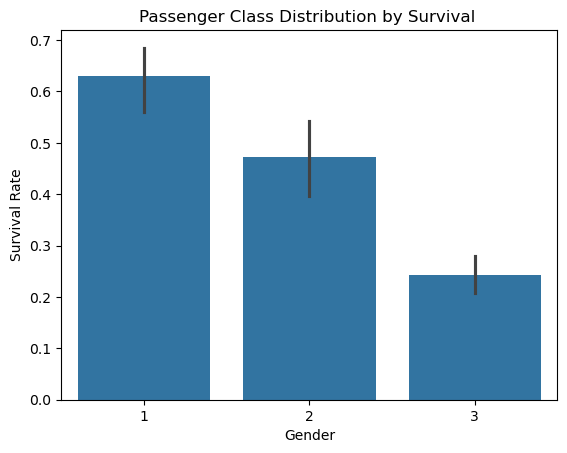

In [13]:
sns.barplot(data= titanic, y= 'Survived', x = 'Pclass')
plt.title("Passenger Class Distribution by Survival ")
plt.ylabel('Survival Rate')
plt.xlabel('Gender')
plt.show()

In [14]:
titanic.groupby("Survived")["Age"].mean()

Survived
0    30.028233
1    28.291433
Name: Age, dtype: float64

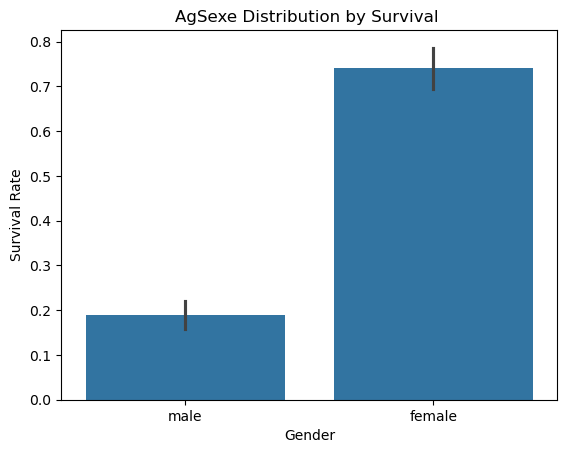

In [15]:
sns.barplot(data= titanic, y= 'Survived', x = 'Sex')
plt.title("AgSexe Distribution by Survival ")
plt.ylabel('Survival Rate')
plt.xlabel('Gender')
plt.show()

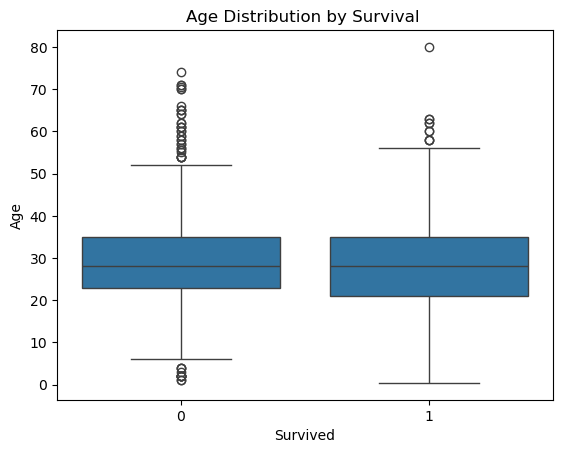

In [16]:
sns.boxplot(data= titanic, x= 'Survived', y = 'Age')
plt.title("Age Distribution by Survival ")
plt.show()

In [17]:
titanic.groupby("SibSp")["Survived"].mean()*100


SibSp
0    34.539474
1    53.588517
2    46.428571
3    25.000000
4    16.666667
5     0.000000
8     0.000000
Name: Survived, dtype: float64

In [18]:
titanic.groupby("Parch")["Survived"].mean()*100


Parch
0    34.365782
1    55.084746
2    50.000000
3    60.000000
4     0.000000
5    20.000000
6     0.000000
Name: Survived, dtype: float64

In [19]:
titanic['Parch'].value_counts().sort_index()

Parch
0    678
1    118
2     80
3      5
4      4
5      5
6      1
Name: count, dtype: int64

In [20]:
titanic["FamilySize"] =  titanic ["SibSp"] + titanic['Parch'] + 1


In [21]:
titanic.groupby("FamilySize")['Survived'].mean() * 100

FamilySize
1     30.353818
2     55.279503
3     57.843137
4     72.413793
5     20.000000
6     13.636364
7     33.333333
8      0.000000
11     0.000000
Name: Survived, dtype: float64

In [22]:
titanic['FamilySize'].value_counts().sort_index()

FamilySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

In [23]:
titanic.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
FamilySize     0
dtype: int64

In [24]:
titanic["Embarked"].fillna(titanic['Embarked'].mode()[0], inplace = True)

In [25]:
titanic["Embarked"].isnull().sum()

np.int64(0)

In [26]:
titanic["Embarked"] = titanic["Embarked"].map({
    "S" : 0,
    "C" : 1, 
    "Q" : 2
})

In [27]:
titanic["Sex"] = titanic["Sex"].map({
    "female" : 0,
    "male" : 1, 
    
})

In [28]:
titanic.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
FamilySize     0
dtype: int64

In [29]:
titanic.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked', 'FamilySize'],
      dtype='object')

In [30]:
x = titanic[[
    'Pclass', 'Sex', 'Age', 'SibSp',
       'Parch',  'Fare', 'Embarked', 'FamilySize'
]]
y = titanic['Survived']

In [31]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state=42
)

model = LogisticRegression(max_iter = 1000)
model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [32]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy : ", accuracy)

Accuracy :  0.7988826815642458


In [33]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test,y_pred)

array([[89, 16],
       [20, 54]])

In [34]:
from sklearn.metrics import classification_report
classification_report(y_test,y_pred)

'              precision    recall  f1-score   support\n\n           0       0.82      0.85      0.83       105\n           1       0.77      0.73      0.75        74\n\n    accuracy                           0.80       179\n   macro avg       0.79      0.79      0.79       179\nweighted avg       0.80      0.80      0.80       179\n'

In [35]:
# Feature importance 
feature_importance = pd.DataFrame({
    "feature" : x.columns,
    "Coefficient" : model.coef_[0]
})

feature_importance.sort_values(
    by= "Coefficient",
    ascending = False
)

,feature,Coefficient
6,Embarked,0.221729
4,Parch,0.030721
5,Fare,0.002879
2,Age,-0.031192
7,FamilySize,-0.132936
3,SibSp,-0.171268
0,Pclass,-0.957617
1,Sex,-2.583056
